In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Load the dataset
df = pd.read_csv('Pt-descriptors.csv')

TARGET_COL = 'Activity'
ID_COL = 'Compound_Name'

y = df[TARGET_COL].values
identifiers = df[ID_COL].values

# Drop target and ID, ensure only numeric features remain
X_raw = df.drop(columns=[TARGET_COL, ID_COL]).select_dtypes(include=[np.number])

print(f"Initial dataset shape: {df.shape}")
print(f"Number of raw descriptors: {X_raw.shape[1]}")

Initial dataset shape: (20, 70)
Number of raw descriptors: 68


In [2]:
# Custom Transformer to drop correlated features dynamically inside the CV pipeline
class CorrelationDropper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold
        self.to_drop_ = []

    def fit(self, X, y=None):
        # Convert to DataFrame to calculate correlation matrix
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        
        # Select upper triangle of correlation matrix
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        # Identify columns to drop
        self.to_drop_ = [column for column in upper.columns if any(upper[column] > self.threshold)]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.drop(columns=self.to_drop_).values

In [3]:
# Print initial count
initial_count = X_raw.shape[1]
print(f"Initial number of descriptors: {initial_count}")

# 1. Static Filtering for Visualization (Variance)
selector = VarianceThreshold(threshold=0.01)
X_var = pd.DataFrame(selector.fit_transform(X_raw), columns=X_raw.columns[selector.get_support()])

# Calculate and print dropped by variance
var_dropped_count = initial_count - X_var.shape[1]
print(f"Descriptors discarded due to low variance: {var_dropped_count}")

# Correlation Filtering
corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

# Calculate and print dropped by correlation
corr_dropped_count = len(to_drop)
print(f"Descriptors discarded due to high correlation: {corr_dropped_count}")

# Apply drop and get final count
X_eda = X_var.drop(columns=to_drop)
final_count = X_eda.shape[1]

# Print final summary
total_discarded = var_dropped_count + corr_dropped_count
print("-" * 40)
print(f"Total descriptors discarded: {total_discarded}")
print(f"Final number of descriptors: {final_count}")

Initial number of descriptors: 68
Descriptors discarded due to low variance: 2
Descriptors discarded due to high correlation: 41
----------------------------------------
Total descriptors discarded: 43
Final number of descriptors: 25


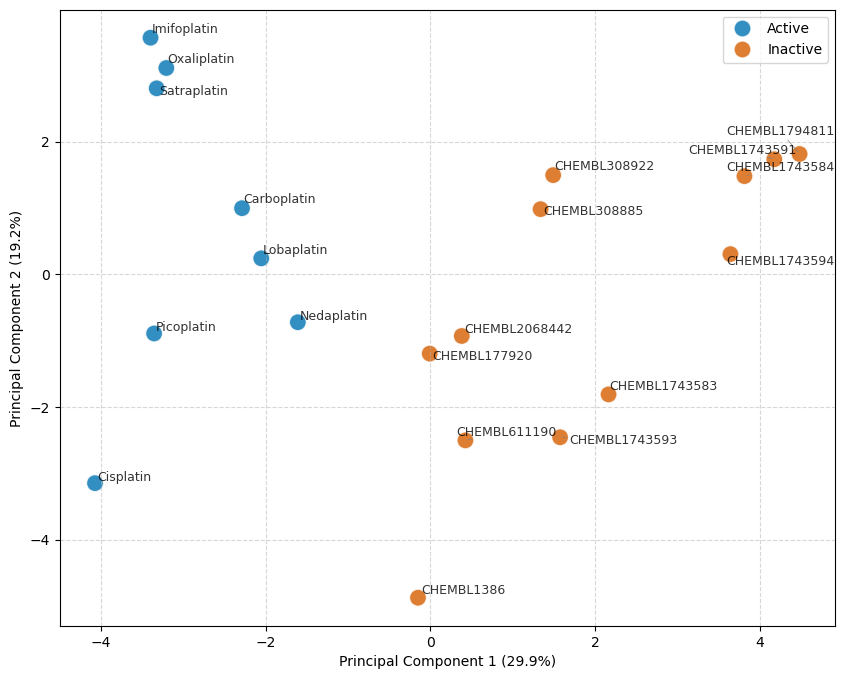

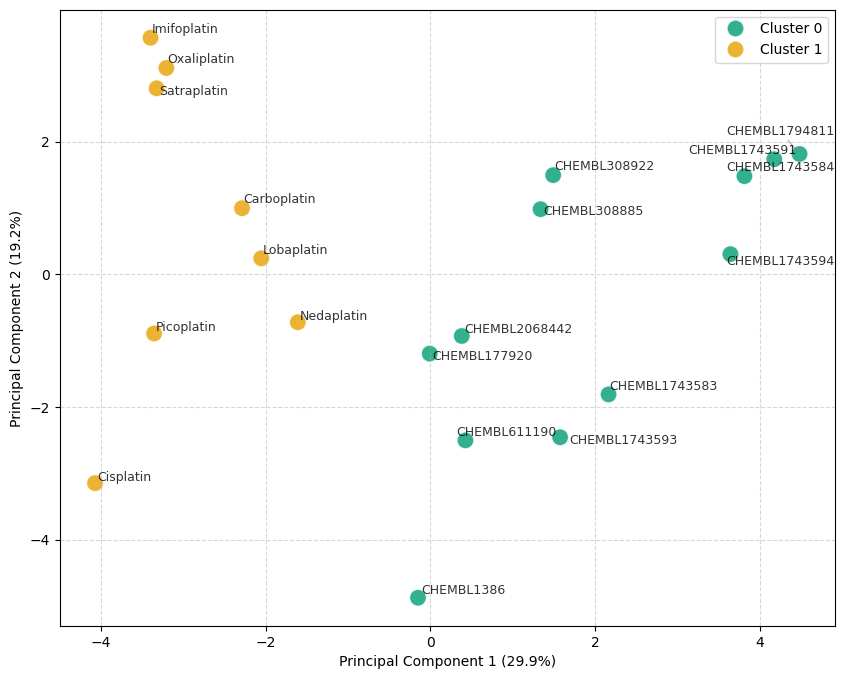

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from adjustText import adjust_text

# 2. PCA & Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_eda)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Create DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'], index=identifiers)
pca_df['Activity'] = ['Active' if val == 1 else 'Inactive' for val in y]

# Add K-Means clusters to DataFrame
pca_df['Cluster'] = clusters 
pca_df['Cluster'] = pca_df['Cluster'].map({0: 'Cluster 0', 1: 'Cluster 1'})

explained_var_title = f"Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%"

# --- Professional Hex Color Palettes ---
pca_palette = {'Active': '#0072B2', 'Inactive': '#D55E00'}
kmeans_palette = {'Cluster 0': '#009E73', 'Cluster 1': '#E69F00'}

# ---------------------------------------------------------
# 3a. Plot 1: Actual Activity (Separate Figure)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Activity', 
    hue_order=['Active', 'Inactive'], 
    palette=pca_palette, 
    data=pca_df, 
    s=150, 
    alpha=0.8
)

# Create text objects and adjust them for Plot 1
texts_pca = []
for idx, row in pca_df.iterrows():
    texts_pca.append(plt.text(row['PC1'], row['PC2'], str(idx), fontsize=9, alpha=0.8))

adjust_text(texts_pca, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show() # Renders the first plot


# ---------------------------------------------------------
# 3b. Plot 2: K-Means Clusters (Separate Figure)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    hue_order=['Cluster 0', 'Cluster 1'], 
    palette=kmeans_palette, 
    data=pca_df, 
    s=150, 
    alpha=0.8
)

# Create text objects and adjust them for Plot 2
texts_kmeans = []
for idx, row in pca_df.iterrows():
    texts_kmeans.append(plt.text(row['PC1'], row['PC2'], str(idx), fontsize=9, alpha=0.8))

adjust_text(texts_kmeans, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show() # Renders the second plot

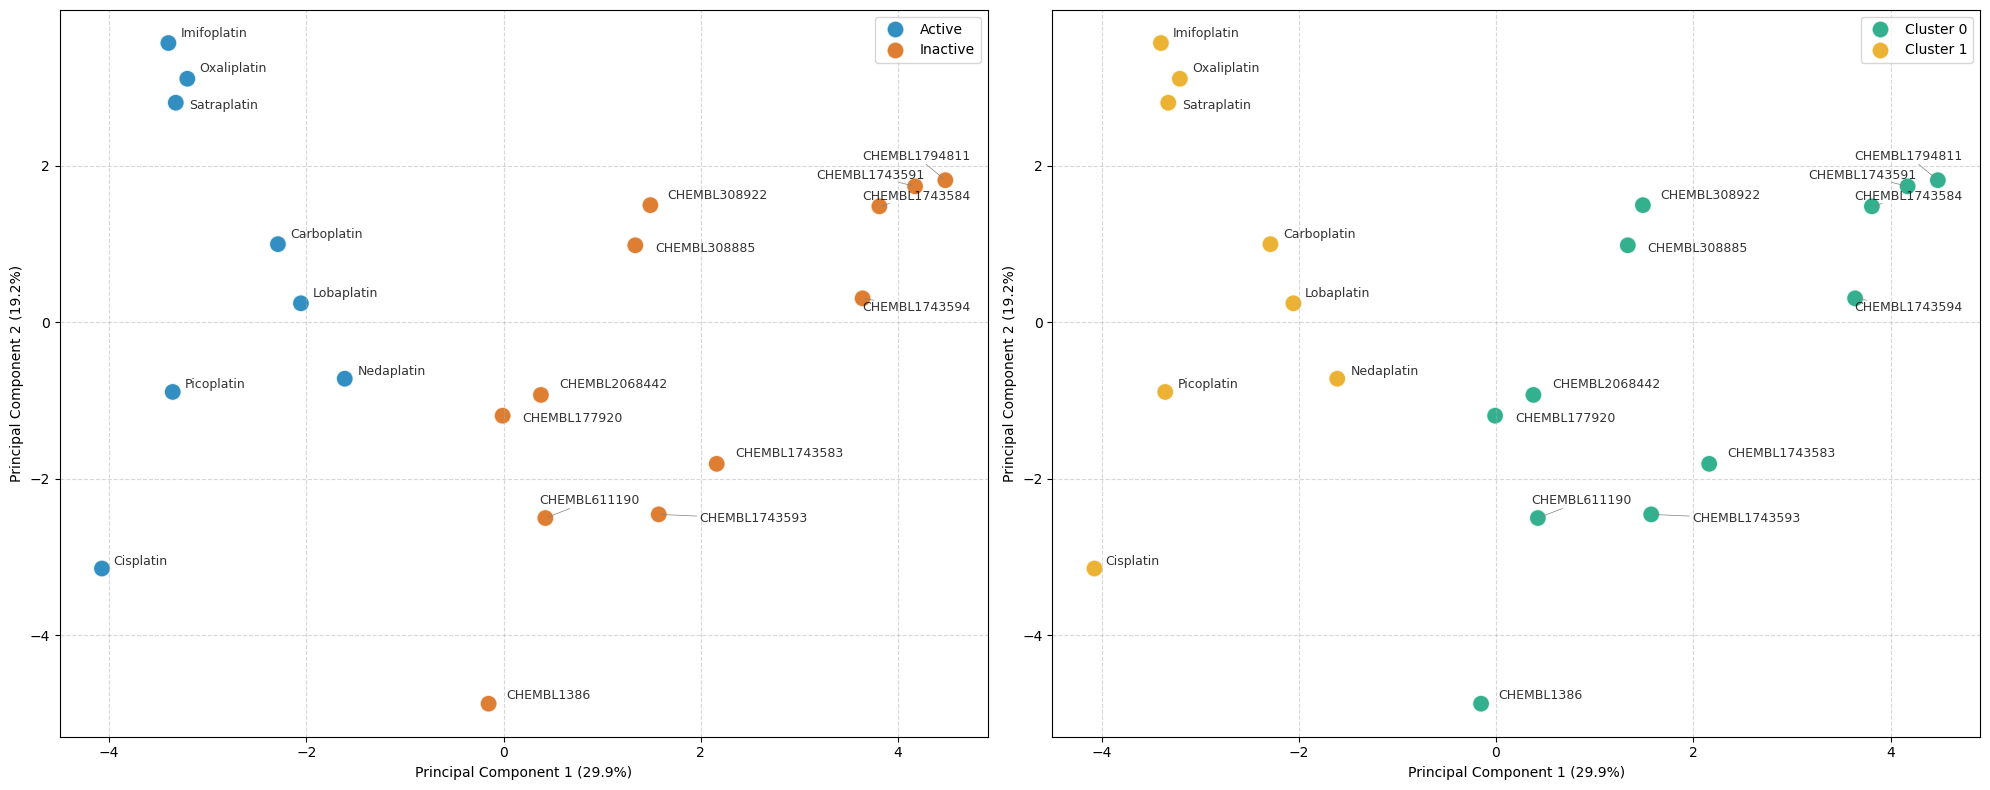

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from adjustText import adjust_text

# 2. PCA & Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_eda)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Create DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'], index=identifiers)
pca_df['Activity'] = ['Active' if val == 1 else 'Inactive' for val in y]

# Add K-Means clusters to DataFrame
pca_df['Cluster'] = clusters 
pca_df['Cluster'] = pca_df['Cluster'].map({0: 'Cluster 0', 1: 'Cluster 1'})

explained_var_title = f"Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%"

# --- Professional Hex Color Palettes ---
pca_palette = {'Active': '#0072B2', 'Inactive': '#D55E00'}
kmeans_palette = {'Cluster 0': '#009E73', 'Cluster 1': '#E69F00'}

# ---------------------------------------------------------
# 3. Plotting (Side-by-Side with adjustText)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Actual Activity ---
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Activity', 
    hue_order=['Active', 'Inactive'], 
    palette=pca_palette, 
    data=pca_df, 
    s=150, 
    alpha=0.8,
    ax=axes[0]
)

# Create text objects and adjust them for Plot 1
texts_pca = []
for idx, row in pca_df.iterrows():
    texts_pca.append(axes[0].text(row['PC1'], row['PC2'], str(idx), fontsize=9, alpha=0.8))

adjust_text(texts_pca, ax=axes[0], arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

axes[0].set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)


# --- Plot 2: K-Means Clusters ---
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    hue_order=['Cluster 0', 'Cluster 1'], 
    palette=kmeans_palette, 
    data=pca_df, 
    s=150, 
    alpha=0.8,
    ax=axes[1]
)

# Create text objects and adjust them for Plot 2
texts_kmeans = []
for idx, row in pca_df.iterrows():
    texts_kmeans.append(axes[1].text(row['PC1'], row['PC2'], str(idx), fontsize=9, alpha=0.8))

adjust_text(texts_kmeans, ax=axes[1], arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

axes[1].set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

----------------------------------------
Top 10 Chemical Descriptors Driving PC1
----------------------------------------
NMR_isotropic_shielding_Pt     -0.287311
HOMO                           -0.273098
Hirsh_CM5_charge_N2            -0.263049
dipole(Debye)                  -0.260384
Hirsh_CM5_charge_N1            -0.251268
Sterimol_L_Pt_N2(Å)_morfeus    -0.232738
polar_iso(au)                   0.225228
Sterimol_B1_Pt_N1(Å)_morfeus    0.239856
Sterimol_B1_Pt_N2(Å)_morfeus    0.261144
Hirsh_atom_dipole_Pt            0.289784
Name: PC1, dtype: float64

----------------------------------------
Top 10 Chemical Descriptors Driving PC2
----------------------------------------
Hirsh_atom_dipole_N2              -0.259745
Hirsh_CM5_charge_N1                0.208235
polar_aniso(au)                    0.220329
Sterimol_B5_Pt_N2(Å)_morfeus       0.251988
distance_Pt_N2(Å)                  0.252002
Sterimol_L_Pt_N2(Å)_morfeus        0.272241
polar_iso(au)                      0.274483
Hirsh_charg

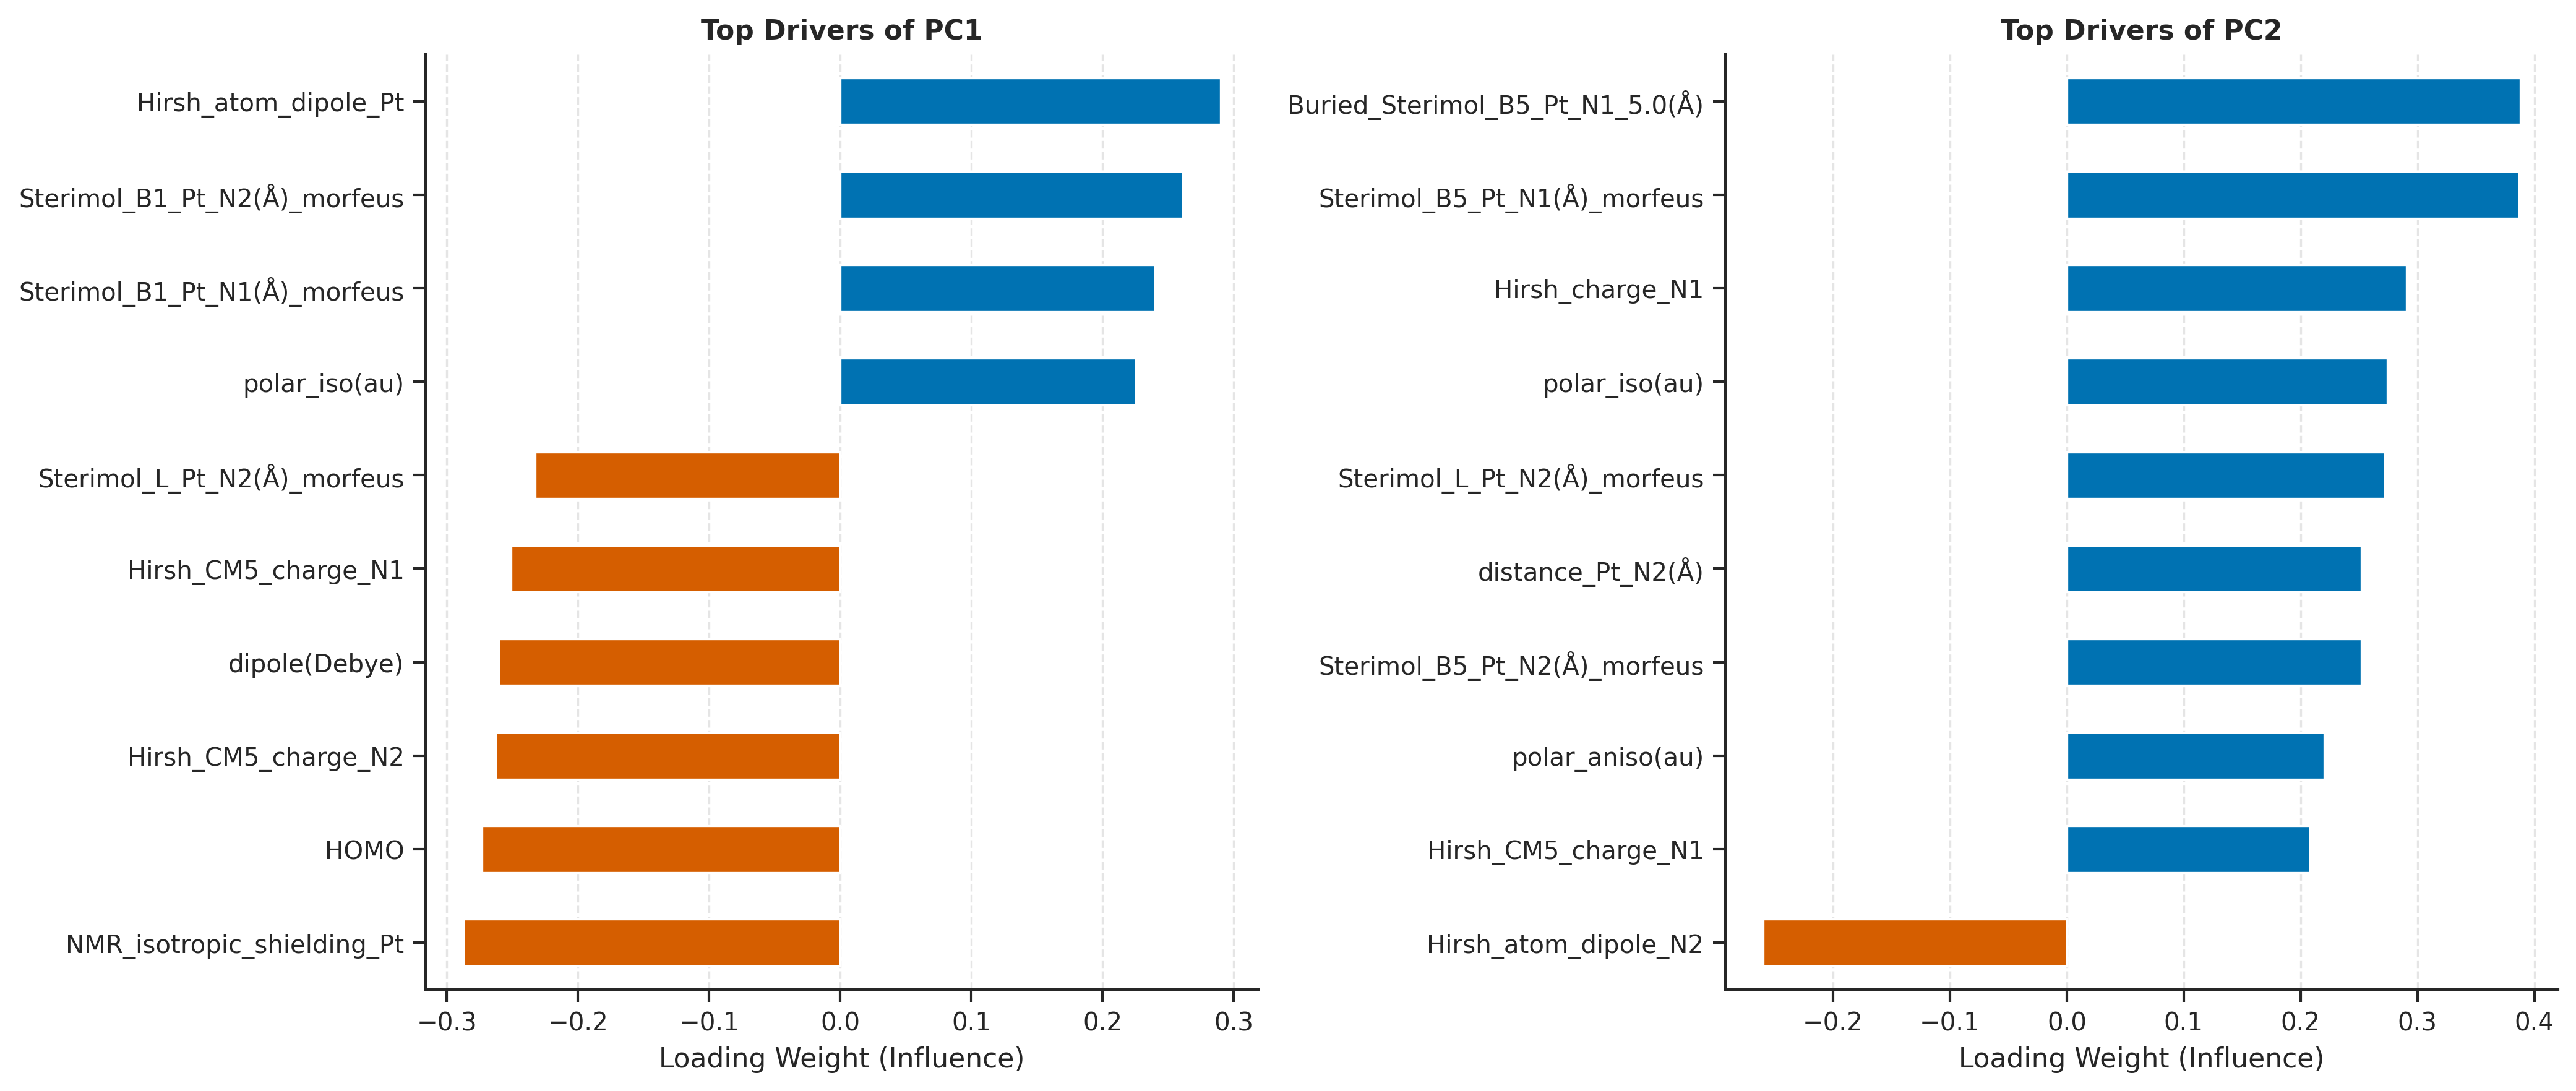

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the PCA loadings into a DataFrame
# pca.components_ contains the weights. We transpose (.T) it so features are rows.
loadings_df = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=X_eda.columns
)

# 2. Function to extract the top N most influential features
def get_top_drivers(pc_name, top_n=10):
    # Sort by absolute value to find the strongest drivers (ignoring sign initially)
    top_features = loadings_df[pc_name].abs().sort_values(ascending=False).head(top_n).index
    # Return the actual positive/negative loading values for those top features
    return loadings_df.loc[top_features, pc_name].sort_values(ascending=True)

# 3. Get the top 10 drivers for PC1 and PC2
top_pc1 = get_top_drivers('PC1', top_n=10)
top_pc2 = get_top_drivers('PC2', top_n=10)

# Print the text summaries to the console
print("-" * 40)
print("Top 10 Chemical Descriptors Driving PC1")
print("-" * 40)
print(top_pc1)
print("\n" + "-" * 40)
print("Top 10 Chemical Descriptors Driving PC2")
print("-" * 40)
print(top_pc2)

# ---------------------------------------------------------
# 4. Visualize the Loadings (Publication Quality Bar Charts)
# ---------------------------------------------------------
sns.set_theme(style="ticks", context="paper", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# Colors: Blue for positive correlation, Red for negative correlation
colors_pc1 = ['#0072B2' if val > 0 else '#D55E00' for val in top_pc1.values]
colors_pc2 = ['#0072B2' if val > 0 else '#D55E00' for val in top_pc2.values]

# --- Bar Chart for PC1 ---
top_pc1.plot(kind='barh', color=colors_pc1, ax=axes[0])
axes[0].set_title("Top Drivers of PC1", fontweight='bold')
axes[0].set_xlabel("Loading Weight (Influence)")
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# --- Bar Chart for PC2 ---
top_pc2.plot(kind='barh', color=colors_pc2, ax=axes[1])
axes[1].set_title("Top Drivers of PC2", fontweight='bold')
axes[1].set_xlabel("Loading Weight (Influence)")
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

Running Strict Leave-One-Out Cross-Validation...

--- LOOCV Model Performance ---
Accuracy: 95.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.88      0.93         8

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



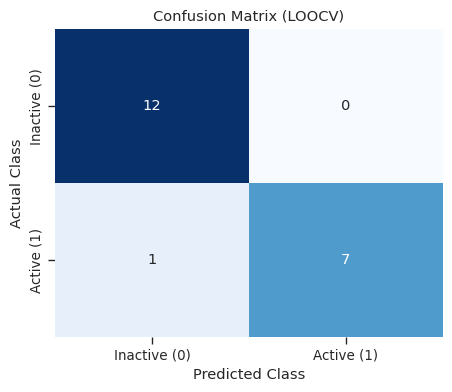

In [7]:
# Construct the strict ML pipeline to prevent data leakage
ml_pipeline = Pipeline([
    ('variance_filter', VarianceThreshold(threshold=0.01)),
    ('scaler', StandardScaler()),
    ('correlation_filter', CorrelationDropper(threshold=0.90)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, class_weight='balanced'))
])

loo = LeaveOneOut()

print("Running Strict Leave-One-Out Cross-Validation...")
y_pred_cv = cross_val_predict(ml_pipeline, X_raw, y, cv=loo)

print(f"\n--- LOOCV Model Performance ---")
print(f"Accuracy: {accuracy_score(y, y_pred_cv)*100:.2f}%\n")
print("Classification Report:")
print(classification_report(y, y_pred_cv))

# Plot Confusion Matrix
cm = confusion_matrix(y, y_pred_cv)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Inactive (0)', 'Active (1)'],
            yticklabels=['Inactive (0)', 'Active (1)'])
plt.title("Confusion Matrix (LOOCV)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

Generating SHAP Explanations...


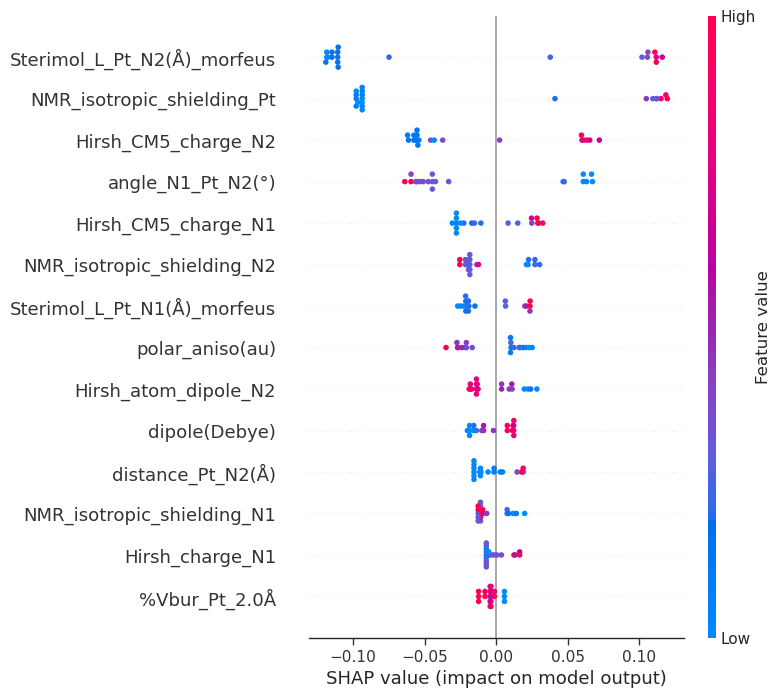

In [8]:
# Train a final model on the filtered DataFrame to retain chemical descriptor names for SHAP
final_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, class_weight='balanced')
final_rf.fit(X_eda, y)

print("Generating SHAP Explanations...")
explainer = shap.TreeExplainer(final_rf)
shap_values = explainer.shap_values(X_eda)

# Robust handling for different SHAP versions (extracting the "Active" class values)
if isinstance(shap_values, list):
    shap_values_active = shap_values[1]
elif len(np.shape(shap_values)) == 3:
    shap_values_active = shap_values[:, :, 1]
else:
    shap_values_active = shap_values

# Plot the SHAP Summary Plot
plt.figure(figsize=(10, 8))
#plt.title("SHAP Summary: What Drives Pt-Complex Activity?", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values_active, X_eda, feature_names=X_eda.columns, show=False, max_display=14)
plt.tight_layout()
plt.show()

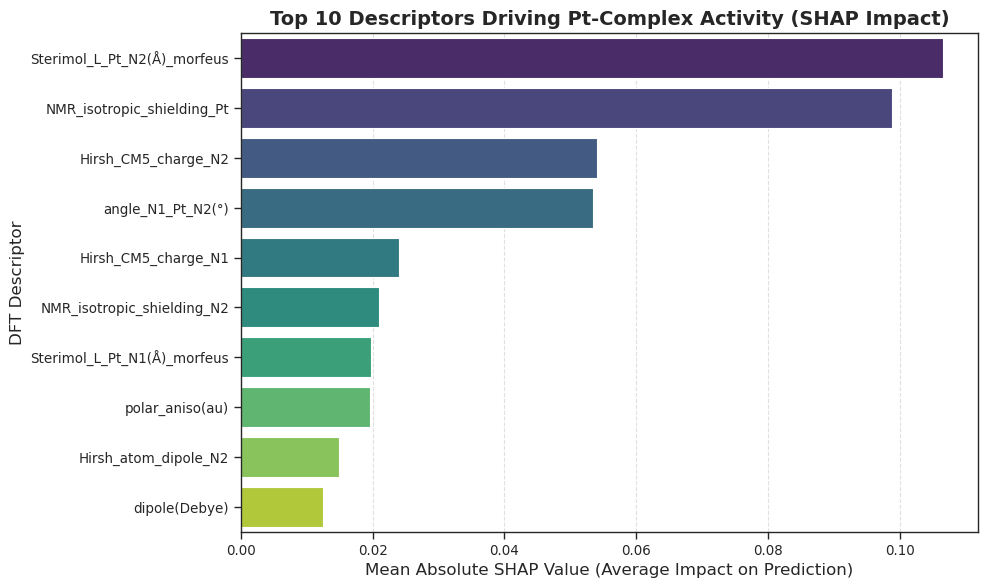

In [9]:
# --- Cell 5b: Top 10 Descriptors Bar Plot (SHAP) ---

# 1. Calculate the mean absolute SHAP value for each feature
# This gives us a single "Importance" score for each descriptor
shap_importance = np.abs(shap_values_active).mean(axis=0)

# 2. Create a DataFrame and sort it
importance_df = pd.DataFrame({
    'Descriptor': X_eda.columns,
    'Importance': shap_importance
}).sort_values(by='Importance', ascending=False)

# Isolate the top 10
top_10_df = importance_df.head(10)

# 3. Plotting the Bar Chart
plt.figure(figsize=(10, 6))

# Using hue='Descriptor' and legend=False avoids the seaborn deprecation warning
sns.barplot(
    x='Importance', 
    y='Descriptor', 
    hue='Descriptor',
    data=top_10_df, 
    palette='viridis',
    legend=False
)

plt.title("Top 10 Descriptors Driving Pt-Complex Activity (SHAP Impact)", fontsize=14, fontweight='bold')
plt.xlabel("Mean Absolute SHAP Value (Average Impact on Prediction)", fontsize=12)
plt.ylabel("DFT Descriptor", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [10]:
# Isolate the compounds the model got wrong during LOOCV
results_df = pd.DataFrame({
    'Compound': identifiers,
    'Actual': y,
    'Predicted': y_pred_cv
})

misclassified = results_df[results_df['Actual'] != results_df['Predicted']]

print("--- Misclassification Audit ---")
if misclassified.empty:
    print("Perfect prediction! No compounds were misclassified in LOOCV.")
else:
    display(misclassified)

--- Misclassification Audit ---


,Compound,Actual,Predicted
16,Nedaplatin,1,0


Generating cross-validated probabilities...


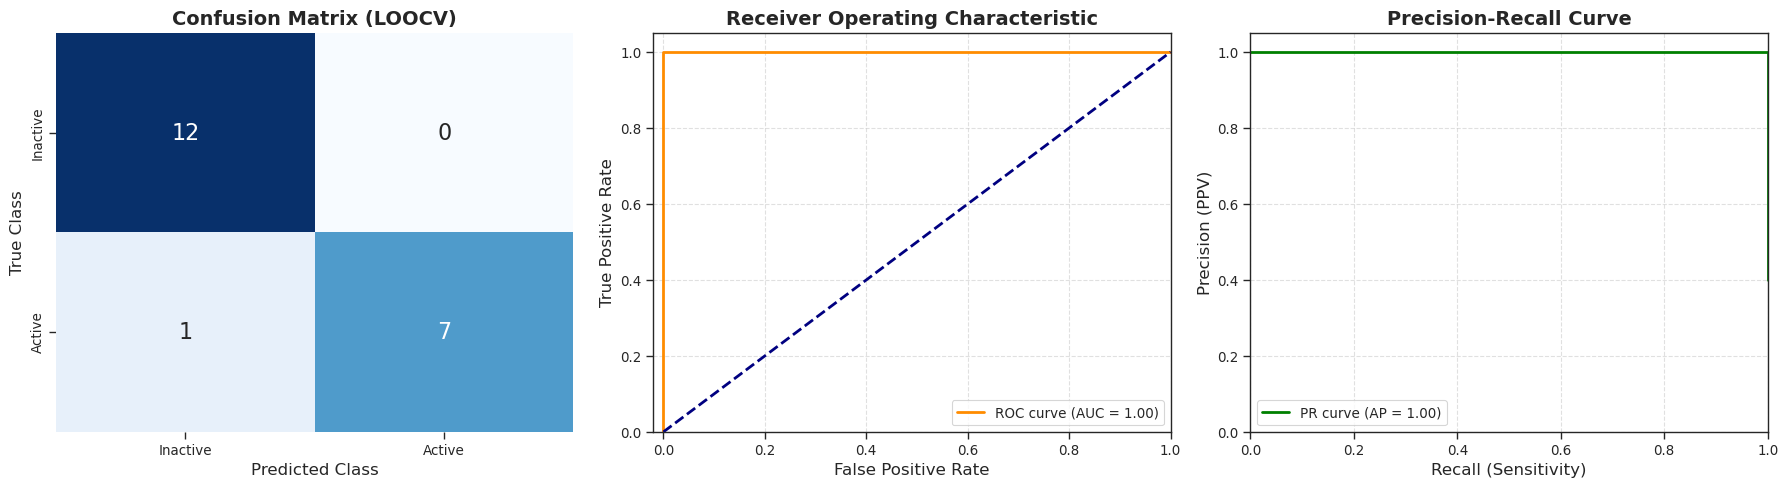

In [11]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Get Probability Predictions using the strict LOOCV pipeline
print("Generating cross-validated probabilities...")
y_probs_cv = cross_val_predict(ml_pipeline, X_raw, y, cv=loo, method='predict_proba')[:, 1]
y_pred_cv = (y_probs_cv >= 0.5).astype(int)

# 2. Calculate Metrics
fpr, tpr, thresholds_roc = roc_curve(y, y_probs_cv)
roc_auc = auc(fpr, tpr)

precision, recall, thresholds_pr = precision_recall_curve(y, y_probs_cv)
pr_auc = average_precision_score(y, y_probs_cv)

cm = confusion_matrix(y, y_pred_cv)

# 3. Create the Dashboard (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'], ax=axes[0],
            annot_kws={"size": 16})
axes[0].set_title('Confusion Matrix (LOOCV)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('True Class', fontsize=12)

# Plot B: ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('Receiver Operating Characteristic', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot C: Precision-Recall Curve
axes[2].plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {pr_auc:.2f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[2].set_ylabel('Precision (PPV)', fontsize=12)
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].legend(loc="lower left")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

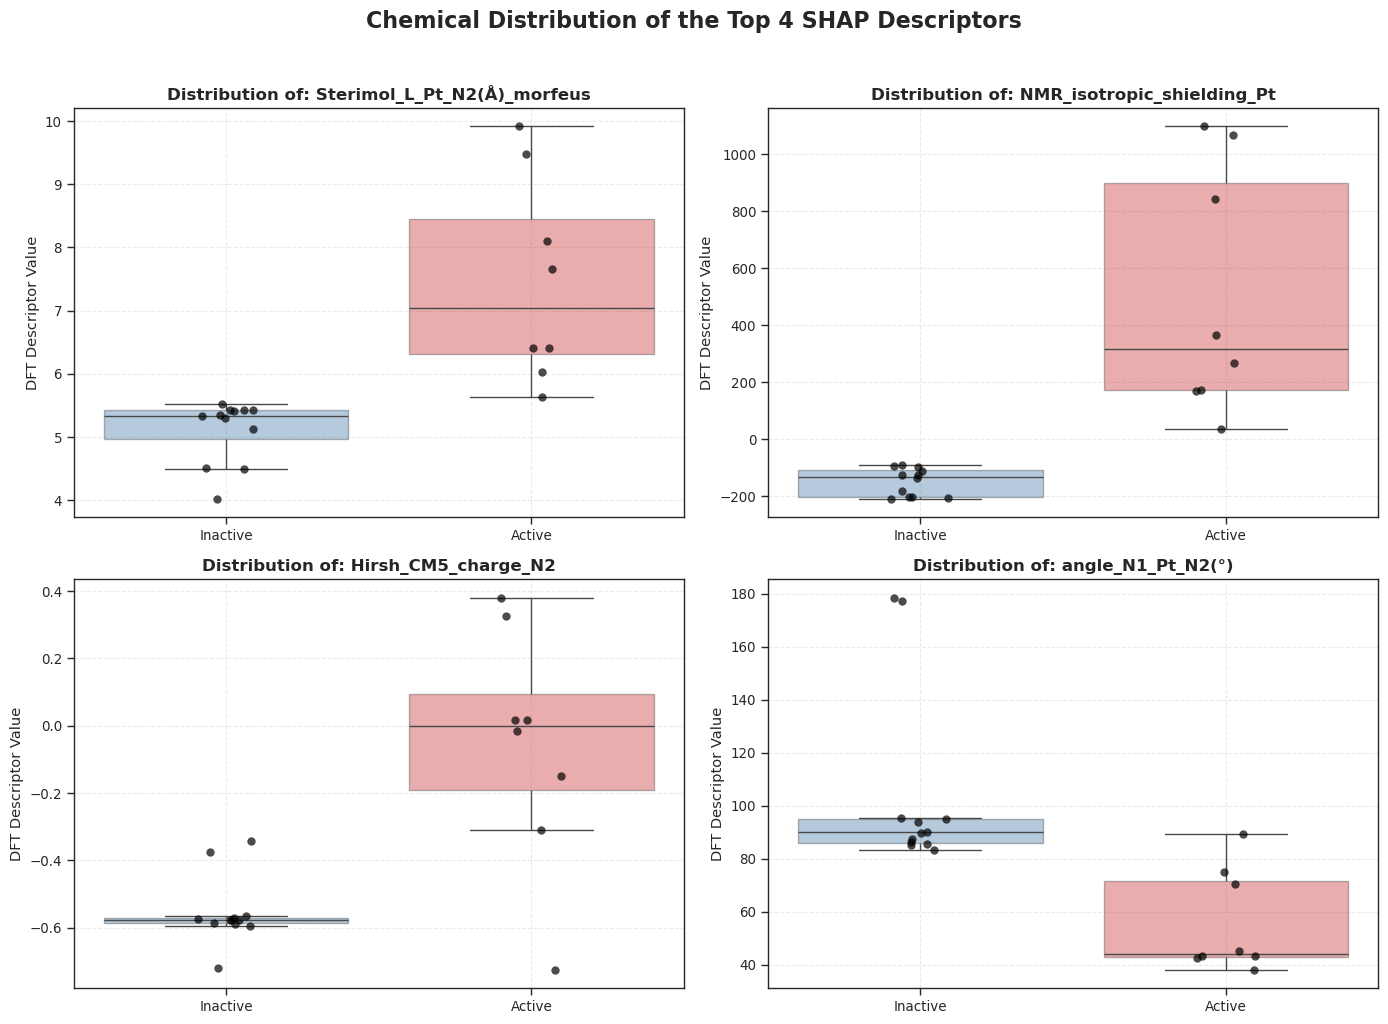

In [12]:
# 1. Dynamically find the top 4 features based on SHAP impact
# Calculate mean absolute SHAP values for each feature
shap_means = np.abs(shap_values_active).mean(axis=0)
top_4_idx = np.argsort(shap_means)[-4:][::-1]
top_4_features = X_eda.columns[top_4_idx].tolist()

# 2. Prepare Data for Plotting
plot_df = X_eda[top_4_features].copy()
plot_df['Activity_Label'] = ['Active' if val == 1 else 'Inactive' for val in y]

# 3. Create a 2x2 grid for the distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
custom_palette = {'Inactive': '#377eb8', 'Active': '#e41a1c'}

# Loop through and plot
for i, feature in enumerate(top_4_features):
    sns.boxplot(
        x='Activity_Label', y=feature, data=plot_df, 
        ax=axes[i], palette=custom_palette, 
        boxprops=dict(alpha=0.4), showfliers=False
    )
    
    sns.stripplot(
        x='Activity_Label', y=feature, data=plot_df, 
        ax=axes[i], color='black', alpha=0.7, jitter=True, size=6
    )
    
    axes[i].set_title(f'Distribution of: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('DFT Descriptor Value')
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Chemical Distribution of the Top 4 SHAP Descriptors', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

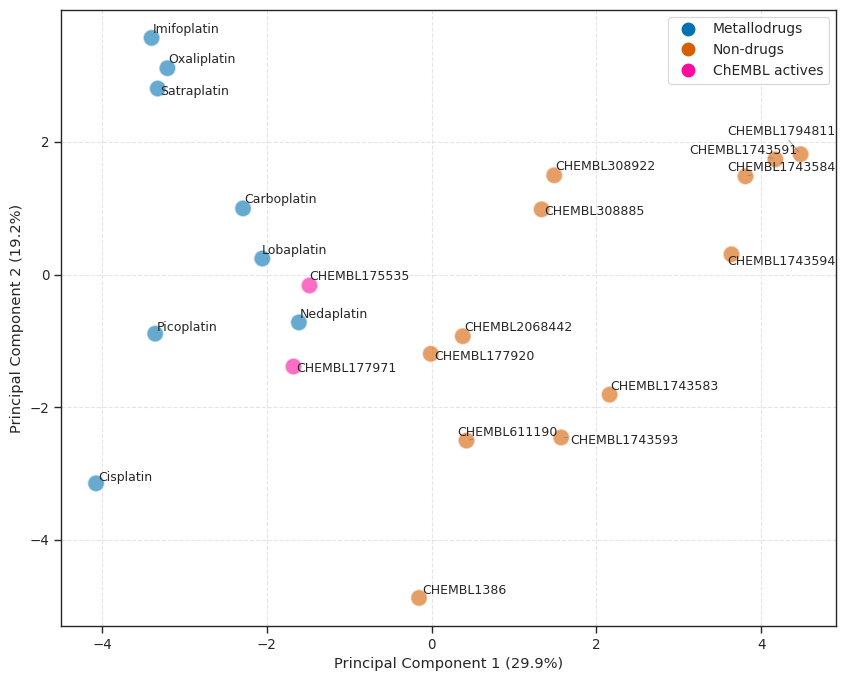

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from adjustText import adjust_text

# ---------------------------------------------------------
# 1. Load, Extract, Scale, and Project ChEMBL Data
# ---------------------------------------------------------
# Load the new ChEMBL actives
df_chembl = pd.read_csv('active-ChEMBL.csv')

# Automatically grab the exact 25 column names from your filtered dataframe
# (Assumes X_eda, scaler, and pca are still in your environment)
features_for_pca = X_eda.columns.tolist()

# Ensure the ChEMBL dataframe has these exact columns
X_chembl = df_chembl[features_for_pca]

# Scale using the ALREADY FITTED scaler
X_chembl_scaled = scaler.transform(X_chembl)

# Project using the ALREADY FITTED pca
pca_chembl_components = pca.transform(X_chembl_scaled)

# Add the calculated coordinates back to the ChEMBL dataframe
df_chembl['PC1'] = pca_chembl_components[:, 0]
df_chembl['PC2'] = pca_chembl_components[:, 1]

# ---------------------------------------------------------
# 2. Plotting the Layered Figure
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Use your exact professional color palette, plus a new one for ChEMBL
pca_palette = {'Active': '#0072B2', 'Inactive': '#D55E00'}
chembl_color = "#FA0C9F"  # Distinct magenta/purple for visibility

# --- A. Background: Original Averaged Structures ---
# Kept your original plot, but lowered alpha slightly to let ChEMBL pop in front
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Activity', 
    hue_order=['Active', 'Inactive'], 
    palette=pca_palette, 
    data=pca_df, 
    s=150, 
    alpha=0.6,       # Dimmed slightly so ChEMBL points are the focal point
    edgecolor='white',
    linewidth=1.2,
    zorder=1,        # Pushed to the background layer
    legend=False     # Custom legend built below
)

# --- B. Foreground: Projected ChEMBL Actives ---
plt.scatter(
    df_chembl['PC1'], df_chembl['PC2'],
    c=chembl_color,
    marker='o',      # Triangles visually separate them from the base circles
    s=150,           # Good size for visibility
    alpha=0.6,
    edgecolor='white',
    linewidth=1.2,
    zorder=1        # Pulled to the foreground
)

# --- C. Aesthetics & Labels ---
texts = []

# 1. Labels for the original averaged structures
for idx, row in pca_df.iterrows():
    texts.append(plt.text(row['PC1'], row['PC2'], str(idx), fontsize=9, zorder=3))

# 2. Labels for the new ChEMBL actives
# Note: If your identifiers are in a specific column instead of the index 
# (e.g., 'ChEMBL_ID' or 'Compound_Name'), replace `str(idx)` with `str(row['ChEMBL_ID'])`
for idx, row in df_chembl.iterrows():
    texts.append(plt.text(
        row['PC1'], row['PC2'], 
        str(row['Compound_Name']), 
        fontsize=9,
        zorder=4
    ))

# Adjust all texts together so they don't overlap
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Build a clean, custom legend for reference structures and ChEMBL species
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#0072B2', markersize=11, label='Metallodrugs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D55E00', markersize=11, label='Non-drugs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=chembl_color, markeredgecolor='white', markersize=11, label='ChEMBL actives')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Apply your exact axes labels and grid
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()